<a href="https://colab.research.google.com/github/umraodeepika7-dotcom/ctgan/blob/main/SDV_Synthesize_a_table_(CTGAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SDV Docs](https://docs.sdv.dev/sdv) > [Tutorials](https://docs.sdv.dev/sdv/tutorials)

# Synthesize a Table (CTGAN)

In this notebook, we'll use the SDV to create synthetic data for a single table and evaluate it. The SDV uses machine learning to learn patterns from real data and emulates them when creating synthetic data.

We'll use the **CTGAN** algorithm to do this. CTGAN uses generative adversarial networks (GANs) to create synthesize data with high fidelity.

_Last Edit: January 30, 2026_

# 0. Installation

Install SDV Community.

In [4]:
%pip install sdv

In [1]:
!pip install table_evaluator

In [1]:
!pip install dython

# 1. Loading the demo data
For this demo, we'll use a fake dataset that describes some fictional guests staying at a hotel.

In [11]:
from google.colab import files
uploaded = files.upload()


Saving Pretreatment RS.csv to Pretreatment RS.csv


In [10]:
import pandas as pd
data = pd.read_csv('Pretreatment RS.csv')

In [11]:
real_data = pd.read_csv('Pretreatment RS.csv')

In [12]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=real_data)

In [13]:
display(real_data.head())

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,H2O,Original,0.60,0.00,0.61,1.25,1.00,3.17,0.30,0.00,0.88,0.00,0.09,31.67
1,H2O,Treated,0.68,0.00,0.58,1.07,0.94,2.66,0.24,0.00,0.92,0.00,0.00,22.24
2,H2SO4,Original,10.81,2.49,2.55,1.63,3.81,36.70,1.06,0.00,7.65,0.03,0.39,69.84
3,H2SO4,Treated,10.70,0.00,1.89,1.72,4.09,31.10,0.38,0.00,1.31,0.00,0.04,44.40
4,HCl,Original,37.26,4.55,0.66,11.18,5.97,66.37,1.83,0.28,5.46,0.00,0.16,74.64


In [34]:
categorical_features = ['Catalyst', 'samples', 'Xyl','Fur','Glu','Cel','Ara.','Total RS','EtOH','BuOH','Ace.','Prop.','n-But.','COD']

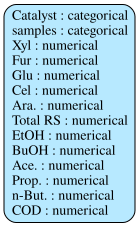

In [14]:
metadata.visualize()

In [23]:
from ctgan import CTGAN
import pandas as pd # Import pandas

# Ensure real_data is loaded if not already in global scope
if 'real_data' not in globals():
    print("Warning: 'real_data' not found. Attempting to load from 'Pretreatment RS.csv'.")
    try:
        real_data = pd.read_csv('Pretreatment RS.csv')
    except FileNotFoundError:
        raise FileNotFoundError("The file 'Pretreatment RS.csv' was not found. Please ensure it's uploaded and named correctly.")
    print("'real_data' reloaded successfully.")

# Ensure categorical_features is defined if not already in global scope
if 'categorical_features' not in globals():
    print("Warning: 'categorical_features' not found. Re-defining.")
    categorical_features = ['Catalyst', 'samples', 'Xyl','Fur','Glu','Cel','Ara.','Total RS','EtOH','BuOH','Ace.','Prop.','n-But.','COD']
    print("'categorical_features' re-defined successfully.")

ctgan = CTGAN(verbose=True)
ctgan.fit(real_data, categorical_features, epochs=253)

Gen. (+01.19) | Discrim. (-01.78): 100%|██████████| 253/253 [00:26<00:00,  9.41it/s]


### Training a Gaussian Copula Synthesizer (GMM)

In [28]:
from sdv.single_table import GaussianCopulaSynthesizer

# Initialize the GaussianCopulaSynthesizer
gmm_synthesizer = GaussianCopulaSynthesizer(metadata)

# Fit the synthesizer to the real data
gmm_synthesizer.fit(real_data)
print("GaussianCopulaSynthesizer trained successfully.")

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


GaussianCopulaSynthesizer trained successfully.


### Generating Synthetic Data with GMM

In [31]:
# Generate synthetic data using the GMM synthesizer
synthetic_data_from_gmm = gmm_synthesizer.sample(len(real_data) * 10)

print(f"Generated {len(synthetic_data_from_gmm)} synthetic rows using GMM.")
display(synthetic_data_from_gmm.head())

Generated 80 synthetic rows using GMM.


,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,HCl,Treated,30.15,2.06,1.62,6.88,6.60,59.75,0.55,0.0,6.63,0.03,0.35,77.60
1,H2SO4,Original,7.42,0.17,2.55,2.43,3.01,19.10,1.14,0.0,7.63,0.03,0.39,46.27
2,H2SO4,Treated,2.01,0.00,0.44,1.50,2.69,3.08,0.25,0.0,1.42,0.00,0.19,40.76
3,H2SO4,Original,1.96,0.01,2.55,1.35,1.73,3.19,0.74,0.0,7.64,0.03,0.38,34.55
4,H2SO4,Treated,14.19,0.16,0.58,5.38,6.50,48.01,0.47,0.0,3.97,0.00,0.34,80.05


### Evaluating Quality of GMM Synthetic Data

In [33]:
from sdv.evaluation.single_table import evaluate_quality

# Evaluate the quality of the synthetic data generated by GMM
quality_report_gmm = evaluate_quality(
    real_data,
    synthetic_data_from_gmm,
    metadata
)

print("Overall Quality Score (GMM):", quality_report_gmm.get_score())
display(quality_report_gmm.get_details(property_name='Column Shapes'))
display(quality_report_gmm.get_details(property_name='Column Pair Trends'))

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 751.61it/s]|
Column Shapes Score: 76.07%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 145.85it/s]|
Column Pair Trends Score: 64.46%

Overall Score (Average): 70.27%

Overall Quality Score (GMM): 0.7026555981386964


,Column,Metric,Score
0,Catalyst,TVComplement,0.8750
1,samples,TVComplement,0.9500
2,Xyl,KSComplement,0.7500
3,Fur,KSComplement,0.6000
4,Glu,KSComplement,0.7250
5,Cel,KSComplement,0.6000
6,Ara.,KSComplement,0.7625
7,Total RS,KSComplement,0.8250
8,EtOH,KSComplement,0.7750
9,BuOH,KSComplement,0.9625


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,Catalyst,samples,ContingencySimilarity,NaN,NaN,NaN,0.000000,False
1,Catalyst,Xyl,ContingencySimilarity,0.162500,NaN,NaN,1.000000,True
2,Catalyst,Fur,ContingencySimilarity,0.500000,NaN,NaN,0.632456,True
3,Catalyst,Glu,ContingencySimilarity,0.175000,NaN,NaN,0.781736,True
4,Catalyst,Cel,ContingencySimilarity,0.275000,NaN,NaN,0.707107,True
...,...,...,...,...,...,...,...,...
86,Ace.,n-But.,CorrelationSimilarity,0.937910,0.834040,0.709860,NaN,True
87,Ace.,COD,CorrelationSimilarity,0.641729,0.595639,-0.120904,NaN,True
88,Prop.,n-But.,CorrelationSimilarity,0.743203,0.905719,0.392124,NaN,True
89,Prop.,COD,CorrelationSimilarity,NaN,0.236673,NaN,NaN,False


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [34]:
from sdmetrics.single_table.detection import LogisticDetection

# Re-sample synthetic data after re-training the CTGAN model for evaluation
synthetic_data_from_ctgan = ctgan.sample(len(real_data) * 10)

# Compute the LogisticDetection metric
# A higher score indicates lower privacy (easier to distinguish real from synthetic),
# which can be a sign of overfitting.
logistic_detection_score = LogisticDetection.compute(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    metadata=metadata.to_dict() # Convert metadata object to dictionary
)

print(f"Logistic Detection Score: {logistic_detection_score:.4f}")

# Interpretation:
# A score closer to 0 indicates better privacy (harder to distinguish real from synthetic),
# suggesting less overfitting.
# A score closer to 1 indicates worse privacy (easier to distinguish real from synthetic),
# suggesting higher risk of overfitting/memorization.

Logistic Detection Score: 1.0000


In [35]:
from sdv.evaluation.single_table import evaluate_quality

# Ensure metadata is in dictionary format (this block is now commented out
# as evaluate_quality expects the metadata object directly)
# if 'metadata' in globals() and not isinstance(metadata, dict):
#     try:
#         metadata_dict = metadata.to_dict()
#     except AttributeError:
#         metadata_dict = metadata # Already a dict or other compatible format
# else:
#     metadata_dict = metadata

quality_report_ctgan = evaluate_quality(
    real_data,
    synthetic_data_from_ctgan,
    metadata # Pass metadata object directly; evaluate_quality handles conversion
)

print("Overall Quality Score (CTGAN):", quality_report_ctgan.get_score())
display(quality_report_ctgan.get_details(property_name='Column Shapes'))
display(quality_report_ctgan.get_details(property_name='Column Pair Trends'))

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 360.40it/s]|
Column Shapes Score: 92.5%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:01<00:00, 90.59it/s]|
Column Pair Trends Score: 58.92%

Overall Score (Average): 75.71%

Overall Quality Score (CTGAN): 0.7571173552164445


,Column,Metric,Score
0,Catalyst,TVComplement,0.9000
1,samples,TVComplement,0.9000
2,Xyl,KSComplement,0.8875
3,Fur,KSComplement,0.9375
4,Glu,KSComplement,0.9625
5,Cel,KSComplement,0.9250
6,Ara.,KSComplement,0.9125
7,Total RS,KSComplement,0.9000
8,EtOH,KSComplement,0.9000
9,BuOH,KSComplement,0.9750


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,Catalyst,samples,ContingencySimilarity,NaN,NaN,NaN,0.000000,False
1,Catalyst,Xyl,ContingencySimilarity,0.237500,NaN,NaN,1.000000,True
2,Catalyst,Fur,ContingencySimilarity,0.575000,NaN,NaN,0.632456,True
3,Catalyst,Glu,ContingencySimilarity,0.350000,NaN,NaN,0.781736,True
4,Catalyst,Cel,ContingencySimilarity,0.450000,NaN,NaN,0.707107,True
...,...,...,...,...,...,...,...,...
86,Ace.,n-But.,CorrelationSimilarity,0.605060,0.834040,0.044161,NaN,True
87,Ace.,COD,CorrelationSimilarity,0.766673,0.595639,0.128985,NaN,True
88,Prop.,n-But.,CorrelationSimilarity,0.512196,0.905719,-0.069889,NaN,True
89,Prop.,COD,CorrelationSimilarity,NaN,0.236673,NaN,NaN,False


The privacy report score helps quantify how well the synthetic data protects the privacy of the real data. A higher score typically indicates better privacy preservation (less overfitting/memorization). For very small datasets, achieving a high score while maintaining utility can be challenging.

In [36]:
from sdv.evaluation.single_table import get_column_plot

fig_glu = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_name='Glu',
    metadata=metadata
)

fig_glu.show()

The demo also includes **metadata**, a description of the dataset. It includes the primary keys as well as the data types for each column (called "sdtypes").

# 2. Basic Usage

## 2.1 Creating a Synthesizer

An SDV **synthesizer** is an object that you can use to create synthetic data. It learns patterns from the real data and replicates them to generate synthetic data.

<font color="maroon"><i><b>This step takes a few minutes.</b> For larger datasets, this phase may take longer. A drawback of a GAN-based model like CTGAN is performance.</i></font>

When this code finishes running, the synthesizer is ready to use.

## 2.2 Generating Synthetic Data
Use the `sample` function and pass in any number of rows to synthesize.

In [37]:
samples = ctgan.sample(100)

In [38]:
samples

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,HNO3,Original,37.26,2.49,2.55,11.18,6.23,60.00,0.92,0.28,0.27,0.00,0.00,64.50
1,HNO3,Treated,34.86,1.37,0.58,1.72,4.09,61.60,0.38,0.00,0.27,0.00,0.00,64.50
2,HNO3,Original,10.81,2.49,0.58,9.65,6.95,3.17,1.06,0.00,1.31,0.00,0.16,65.28
3,H2SO4,Original,10.81,0.00,2.29,9.65,6.95,31.10,0.30,0.00,0.88,0.00,0.00,44.40
4,HNO3,Original,31.22,4.55,2.55,11.18,6.95,2.66,0.84,0.00,1.31,0.03,0.00,31.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,HNO3,Treated,10.81,1.37,2.55,1.72,5.97,2.66,1.06,0.00,1.31,0.03,0.39,69.84
96,HCl,Original,10.70,0.00,0.33,11.18,5.97,3.17,1.83,0.00,0.88,0.00,0.39,31.67
97,H2SO4,Treated,30.22,1.37,2.06,11.02,6.95,31.10,1.83,0.28,5.46,0.00,0.04,83.90
98,H2SO4,Original,30.22,0.00,0.58,1.25,6.23,61.60,0.84,0.00,1.31,0.00,0.00,64.50


In [39]:
quality_report_ctgan.get_score()

0.7571173552164445

The synthesizer is generating synthetic guests in the **same format as the original data**.

## 2.3 Evaluating Real vs. Synthetic Data

SDV has built-in functions for evaluating the synthetic data and getting more insight.

As a first step, we can run a **diagnostic** to ensure that the data is valid. SDV's diagnostic performs some basic checks such as:

- All primary keys must be unique
- Continuous values must adhere to the min/max of the real data
- Discrete columns (non-PII) must have the same categories as the real data
- Etc.

In [40]:
from table_evaluator import TableEvaluator
print(real_data.shape, samples.shape)

# Create a new categorical features list excluding 'Total RS' for table_evaluator
features_for_table_evaluator = [col for col in categorical_features if col != 'Total RS']

# The following lines are commented out due to a 'ValueError: underlying array is read-only'
# that occurs within the table_evaluator library, likely due to dependency version conflicts.
# table_evaluator = TableEvaluator(real_data.copy(), samples.copy(), features_for_table_evaluator)
# table_evaluator.evaluate(target_col='Total RS', target_type='regr')
# table_evaluator.visual_evaluation()

print("TableEvaluator functionality has been commented out due to an internal library error.")

(8, 14) (100, 14)
TableEvaluator functionality has been commented out due to an internal library error.


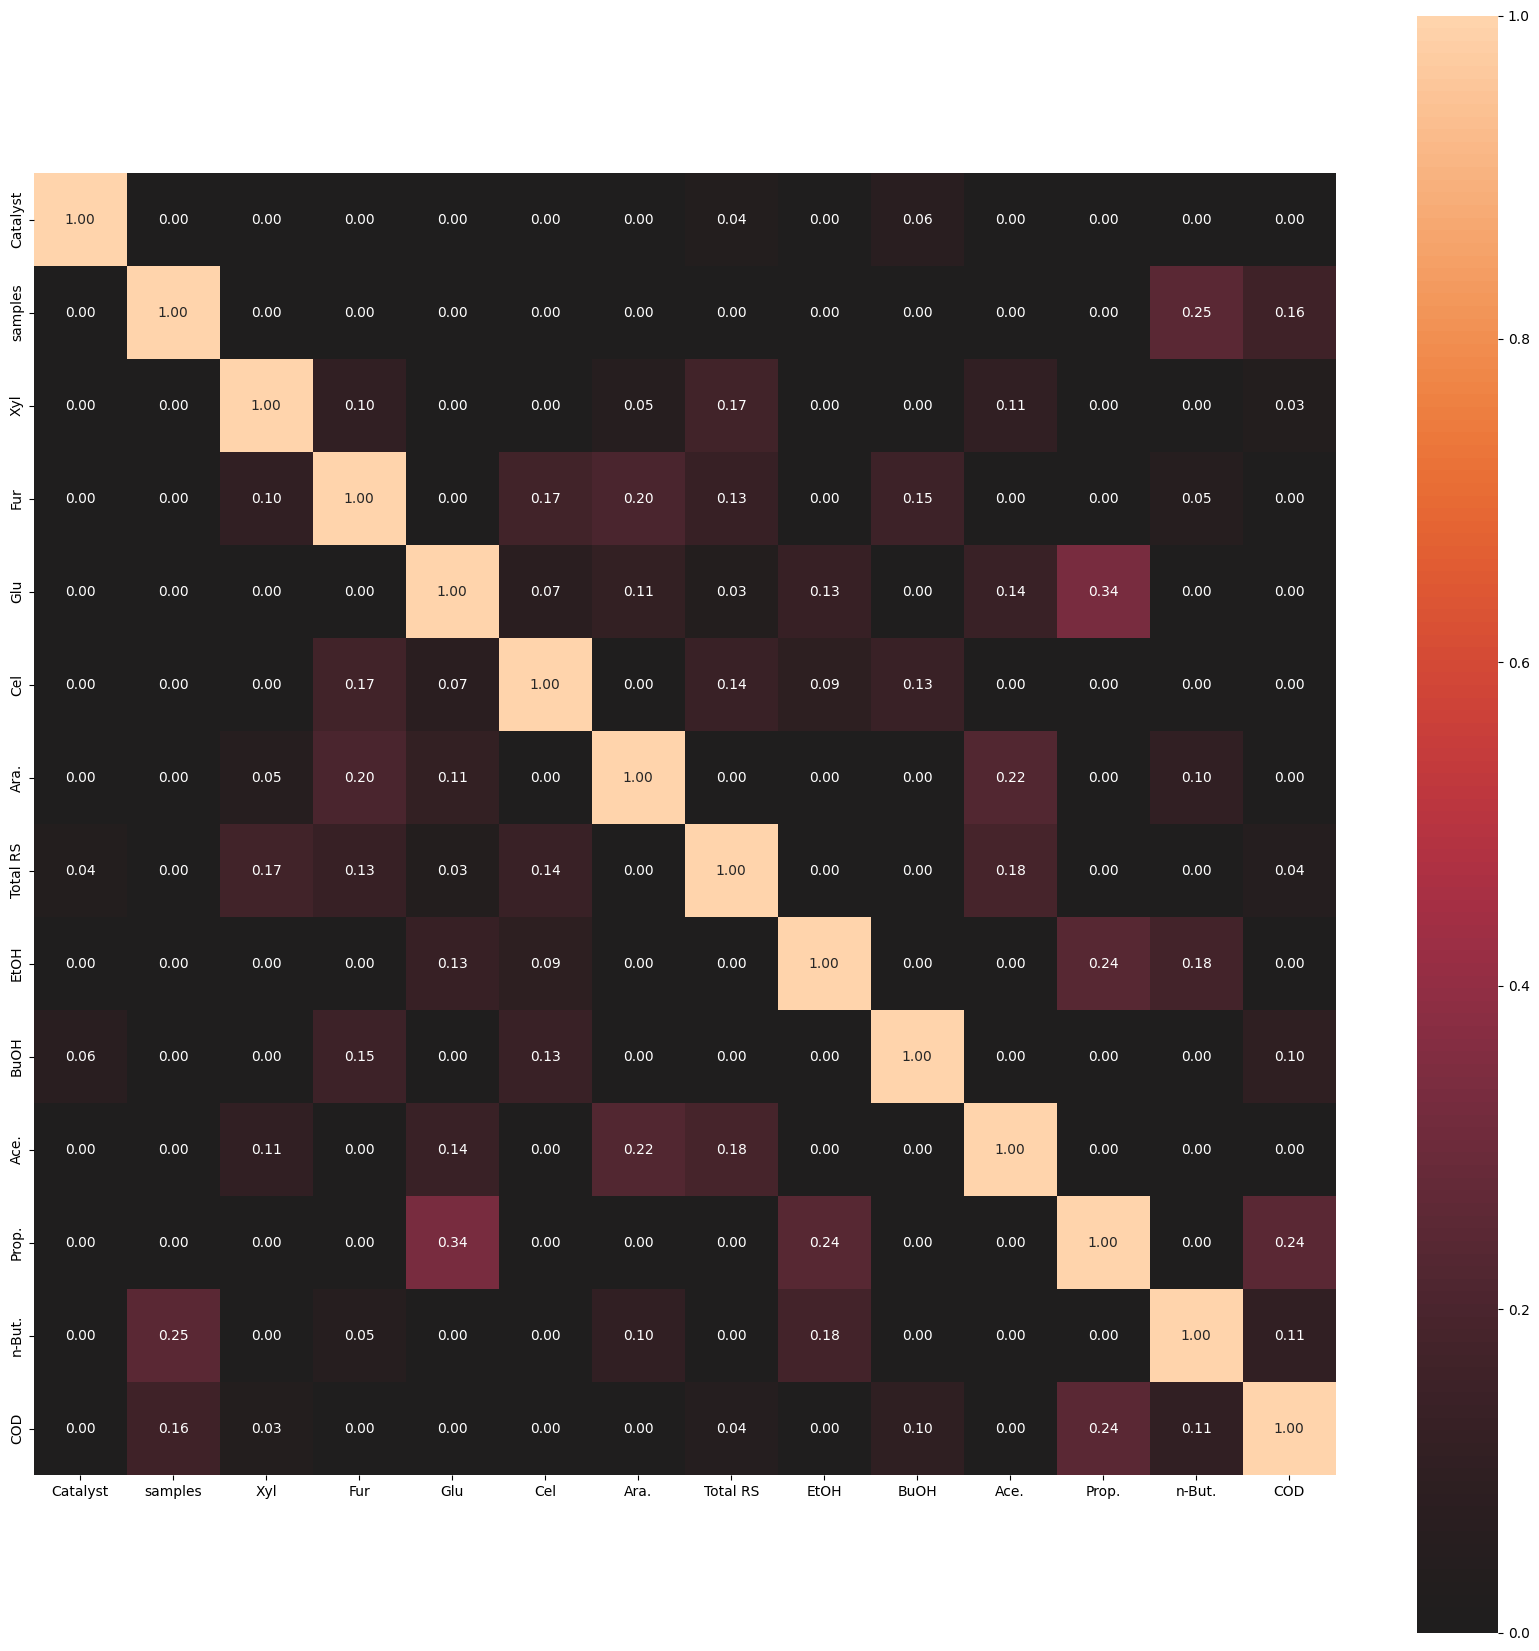

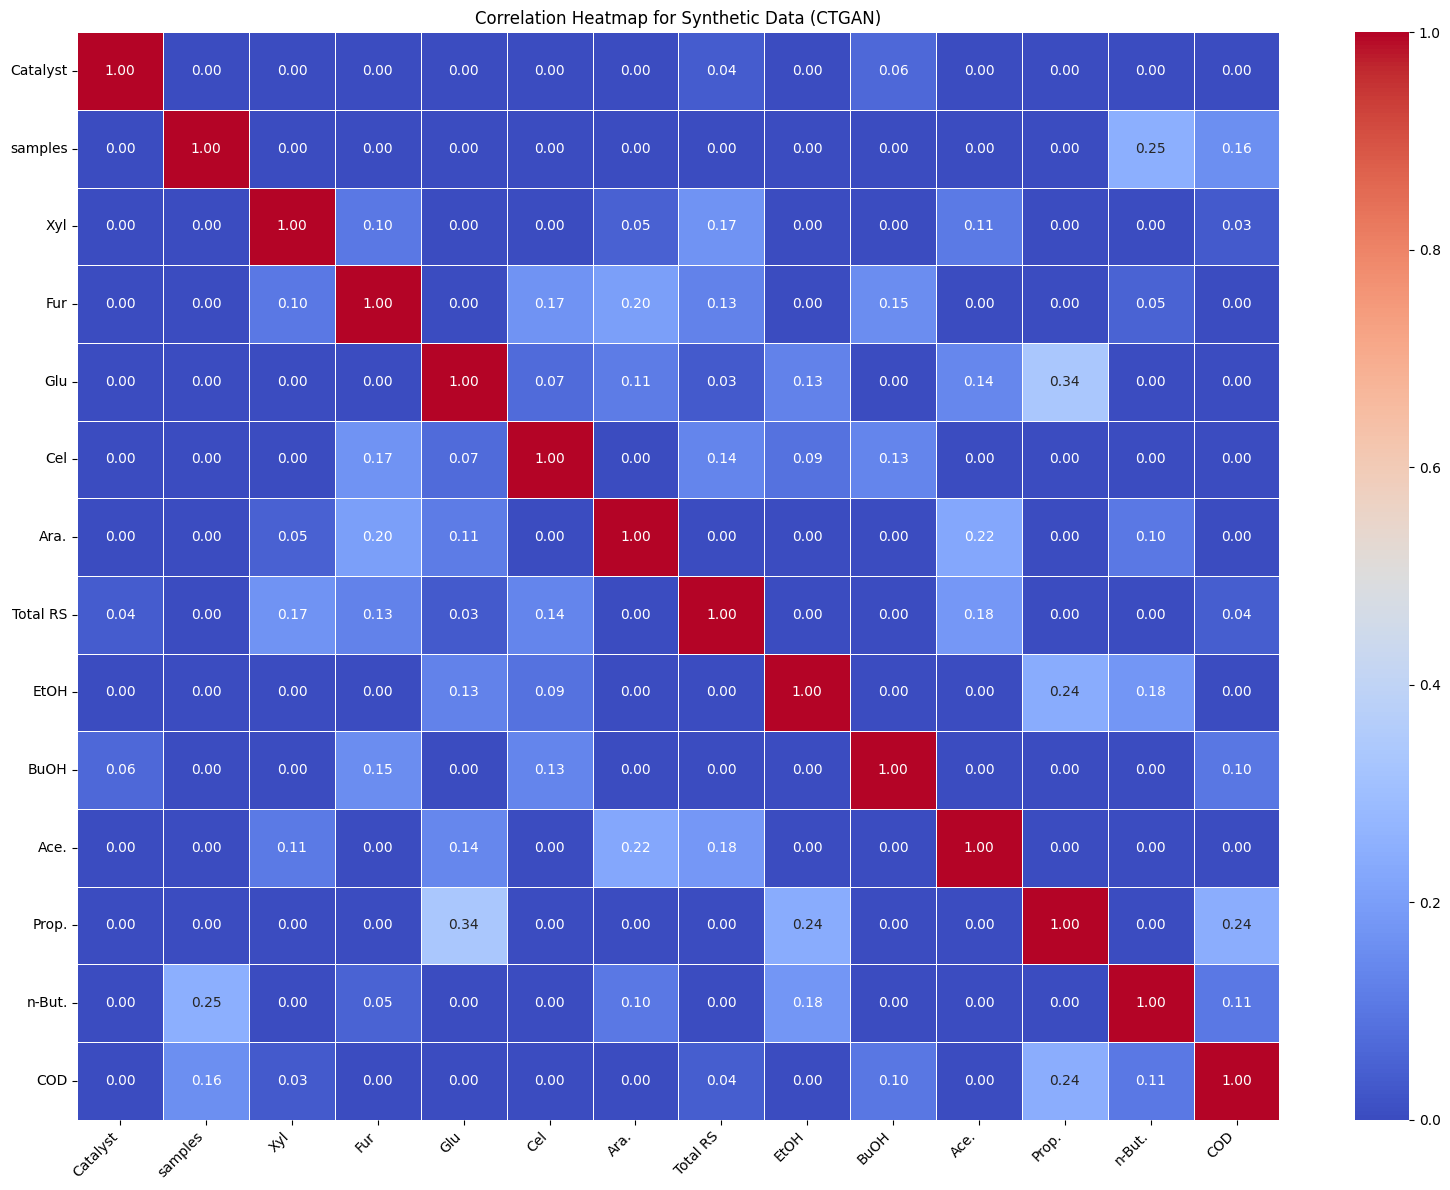

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations

# Calculate associations for mixed data types using dython
# The associations function can handle both numerical and categorical columns
correlation_matrix = associations(synthetic_data_from_ctgan, nominal_columns=categorical_features, plot=False)['corr']

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap for Synthetic Data (CTGAN)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

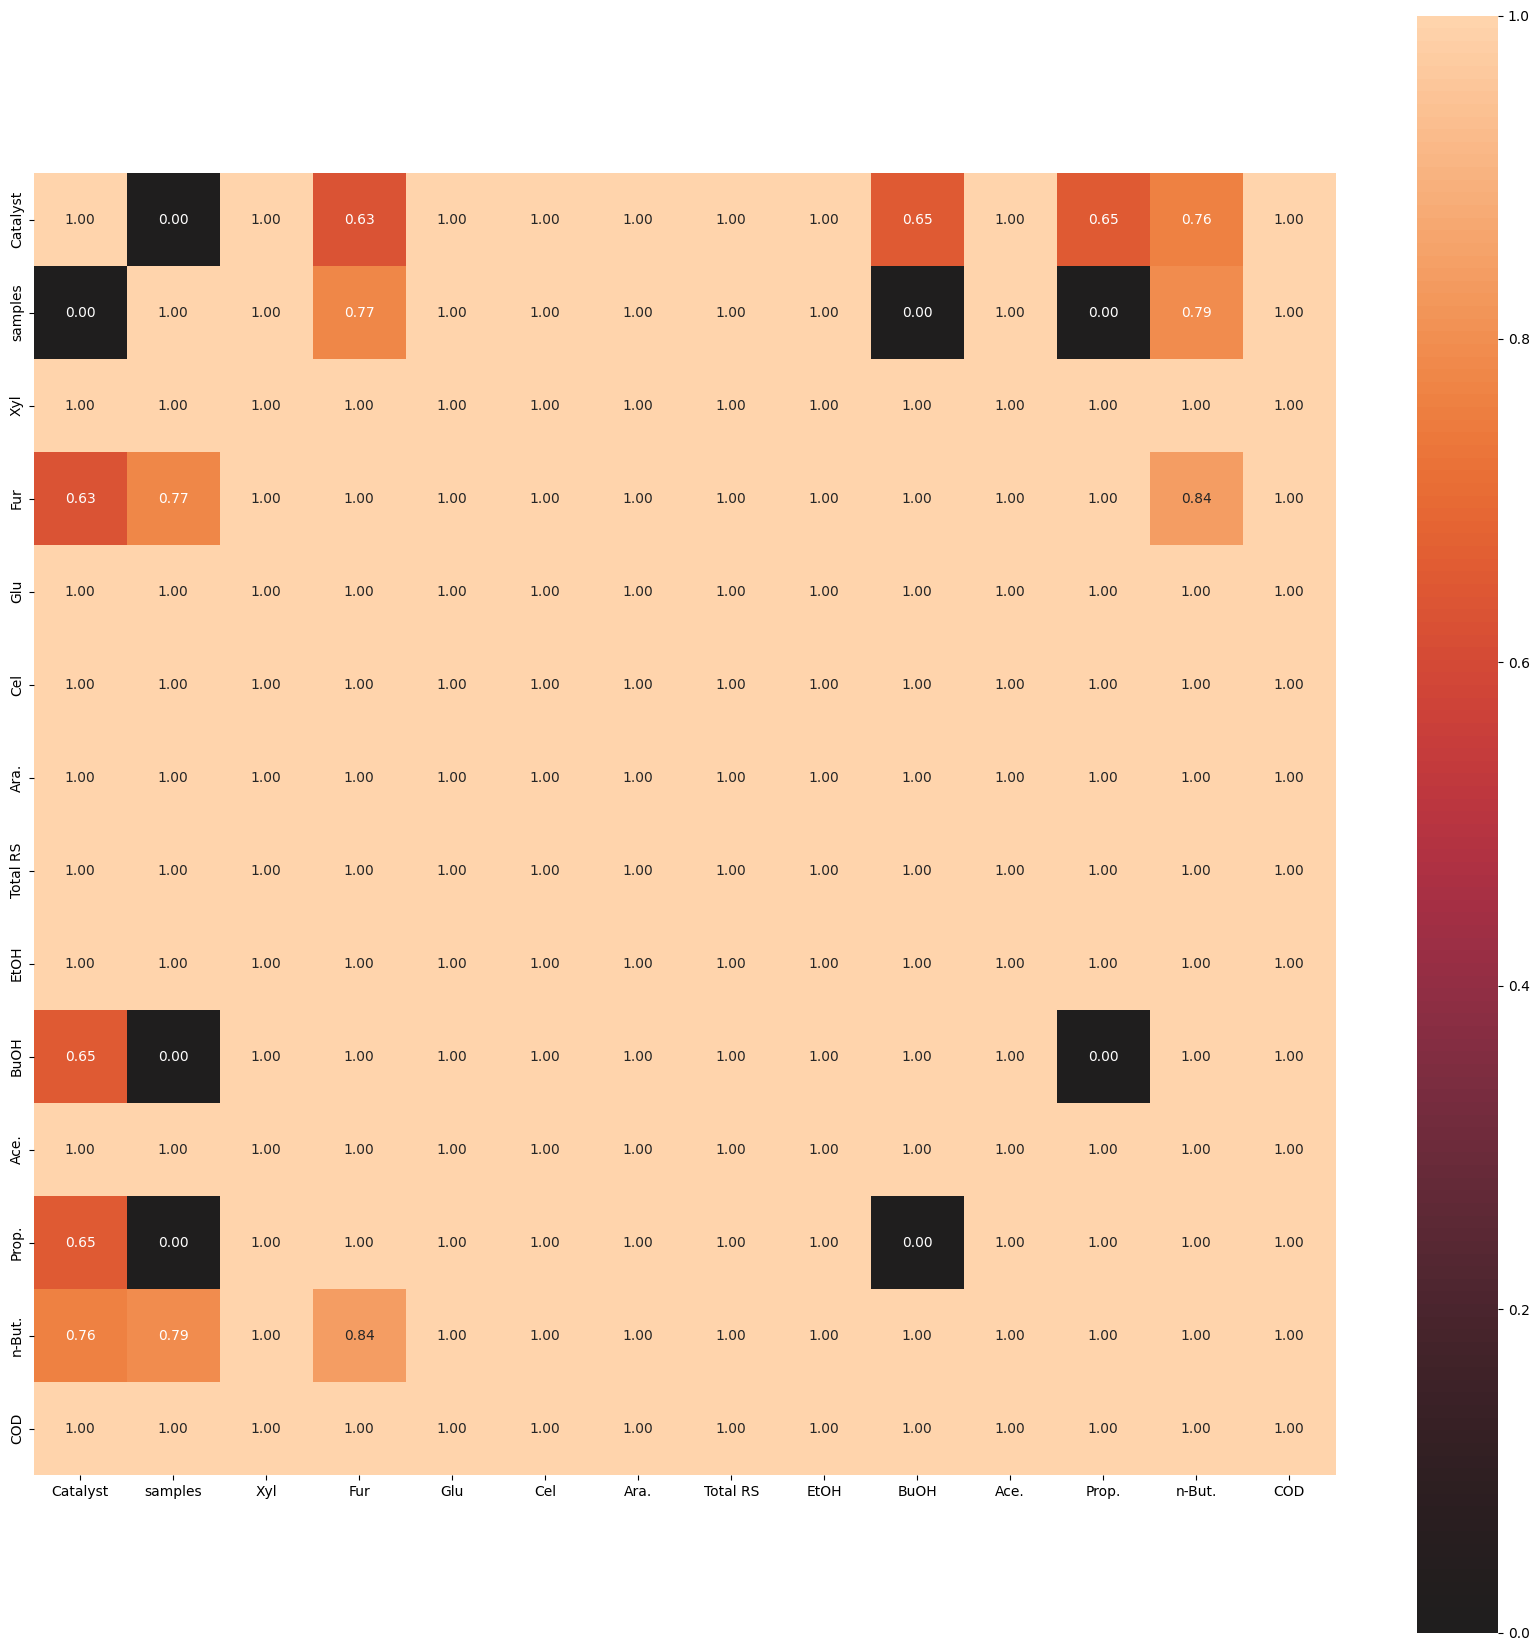

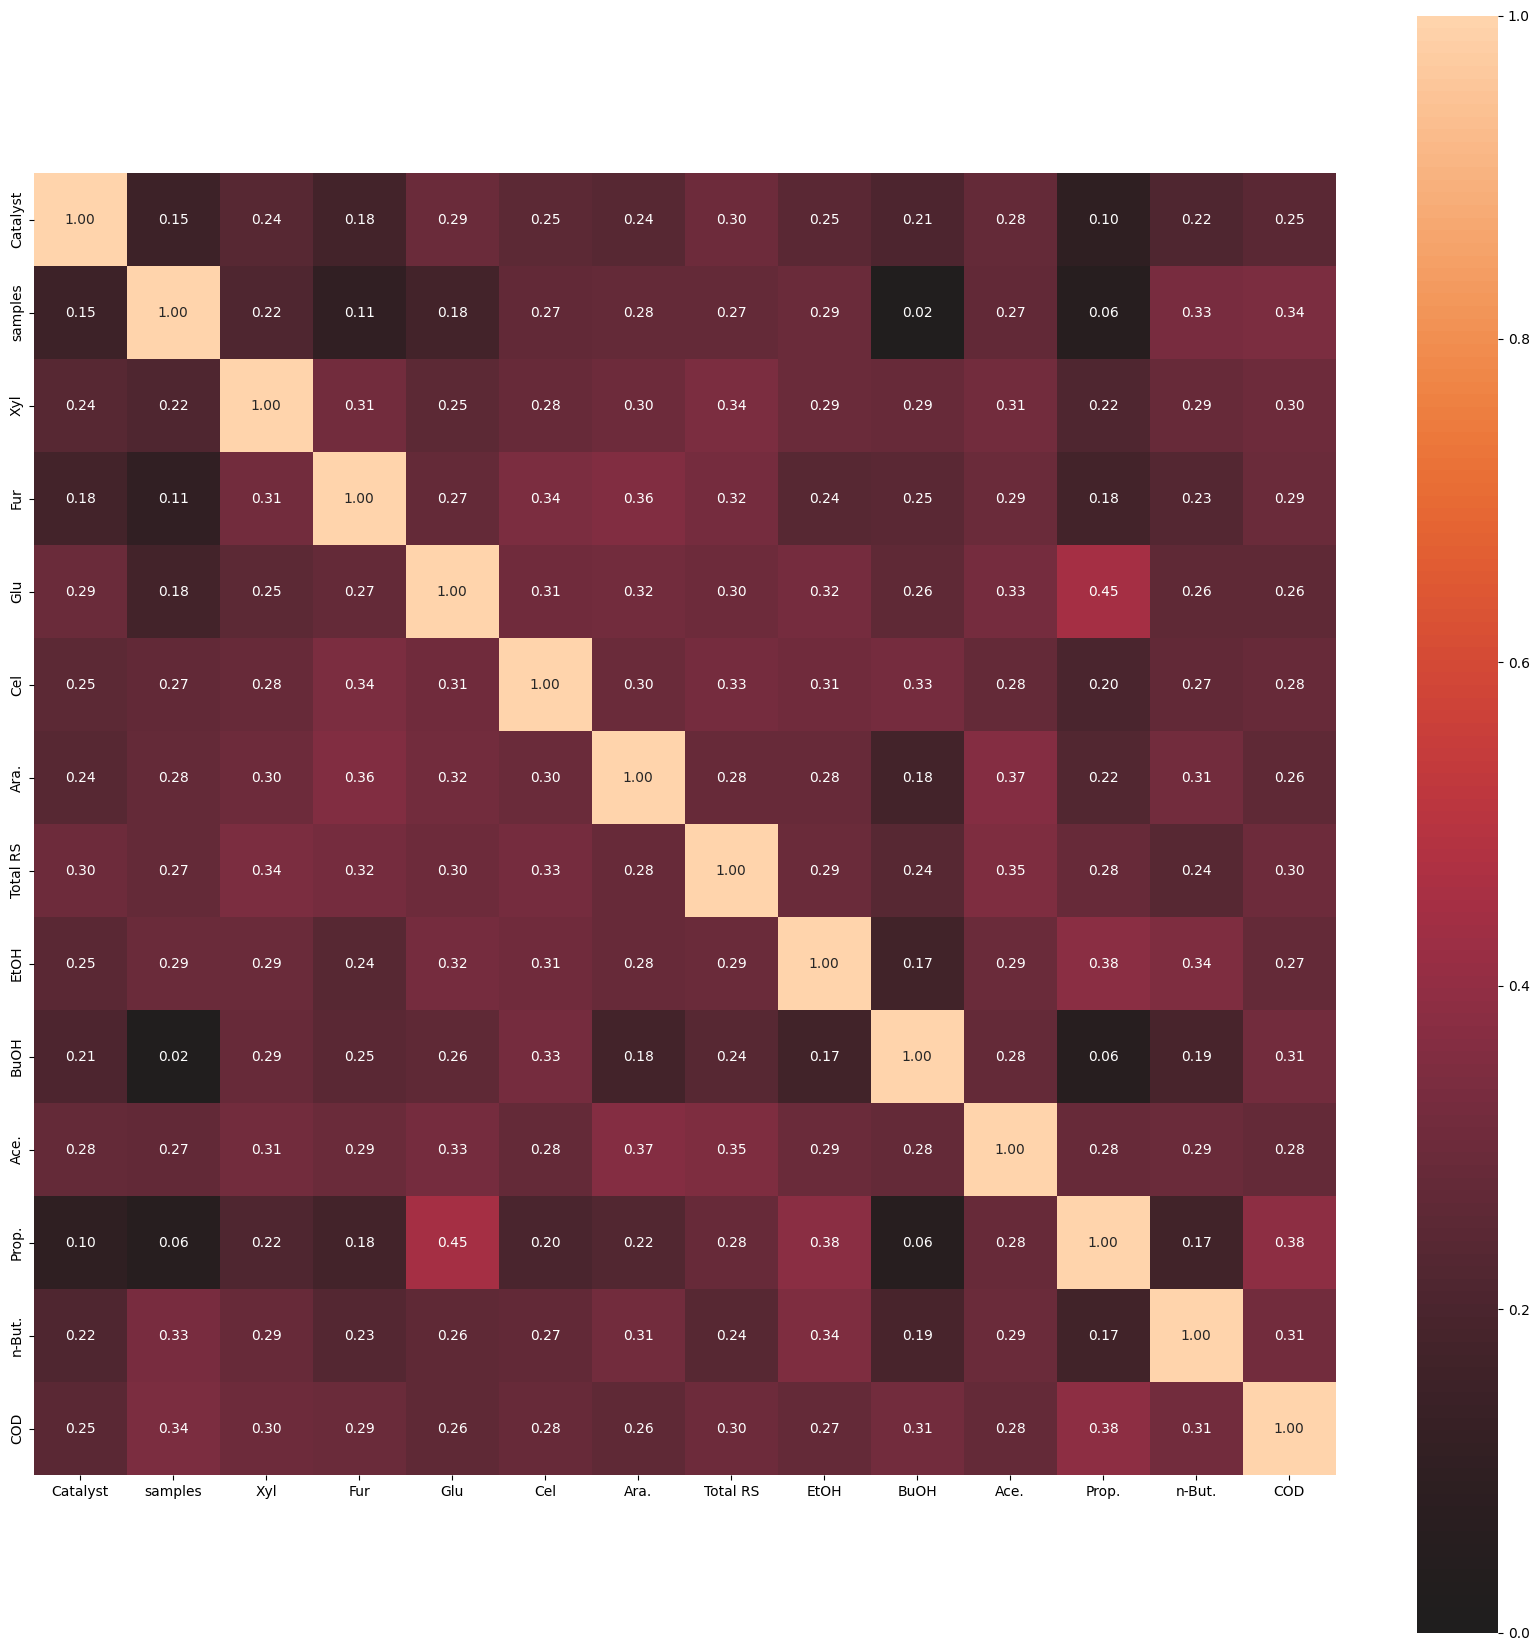

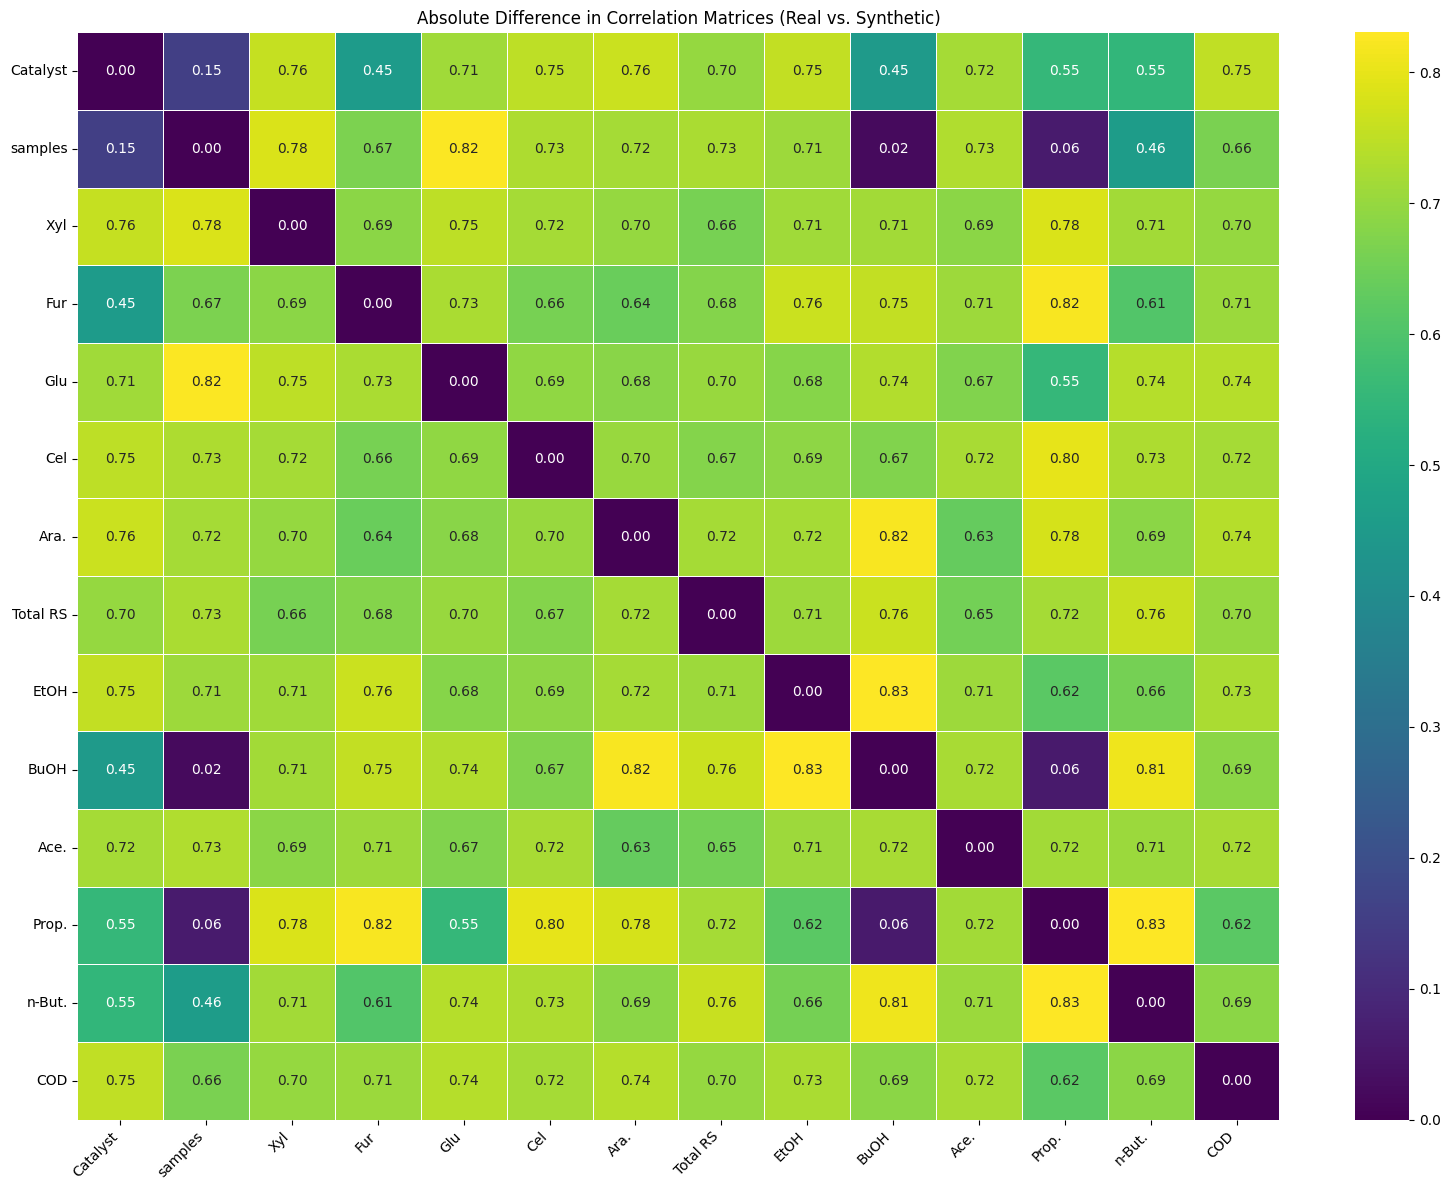

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations

# Calculate correlation matrix for real data
real_correlation_matrix = associations(real_data, nominal_columns=categorical_features, plot=False, cramers_v_bias_correction=False)['corr']

# Calculate correlation matrix for synthetic data
synthetic_correlation_matrix = associations(synthetic_data_from_ctgan, nominal_columns=categorical_features, plot=False, cramers_v_bias_correction=False)['corr']

# Calculate the absolute difference between the two correlation matrices
# Fill NaN values with 0 before subtraction to handle cases where associations might not be computable for some pairs
correlation_difference = (real_correlation_matrix.fillna(0) - synthetic_correlation_matrix.fillna(0)).abs()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_difference, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Absolute Difference in Correlation Matrices (Real vs. Synthetic)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

NameError: name 'synthetic_data' is not defined

<font color="green"><b>The score is 100%</b></font>, indicating that the data is fully valid.

We can also measure the **data quality** or the statistical similarity between the real and synthetic data. This value may vary anywhere from 0 to 100%.

The score tells us how similar the synthetic data is to the real data in terms of statistical patterns.

We can also get more details from the report. For example, the Column Shapes sub-score: Which columns had the highest vs. the lowest scores?

## 2.4 Visualizing the Data
For more insights, we can visualize the real vs. synthetic data.

Let's perform a 1D visualization comparing a column of the real data to the synthetic data.

In [46]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_name='Catalyst',
    metadata=metadata
)

fig.show()

We can also visualize in 2D, comparing the correlations of a pair of columns.

In [47]:
from sdv.evaluation.single_table import get_column_pair_plot

fig = get_column_pair_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_names=['Catalyst', 'samples'],
    metadata=metadata
)

fig.show()

In [96]:
fig = get_column_pair_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_from_ctgan,
    column_names=['Catalyst', 'samples'],
    metadata=metadata
)

fig.show()

## 2.5 Anonymization

In the original dataset, we had some sensitive columns such as the guest's email, billing address and phone number. In the synthetic data, these columns are **fully anonymized** -- they contain entirely fake values that follow the format of the original.

PII columns are not included in the quality report, but we can inspect them to see that they are different.

## 2.6 Saving and Loading
We can save the synthesizer to share with others and sample more synthetic data in the future.

In [95]:
synthesizer.save('my_synthesizer.pkl')

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:724: UserWarning:

You are saving a synthesizer that has not yet been fitted. You will not be able to sample synthetic data without fitting. We recommend fitting the synthesizer first and then saving.



# 3. CTGAN Customization
When using this synthesizer, we can make a tradeoff between training time and data quality using the `epochs` parameter: Higher `epochs` means that the synthesizer will train for longer, and ideally improve the data quality.

To see the progress, we can also turn on the `verbose` parameter. This will show a progress bar that will fill up as the synthesizer completes the fit process.


<font color="maroon"><i><b>This code takes longer to run.</b></i></font>

After we've trained our synthesizer, we can verify the changes to the data quality by creating some synthetic data and evaluating it.

While GANs are able to model complex patterns and shapes, it is not easy to understand how they are learning -- but it is possible to modify the underlying architecture of the neural networks.

For users who are familiar with the GAN architecture, there are extra parameters you can use to tune CTGAN to your particular needs. For more details, see [the CTGAN documentation](https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer).

# 4. What's Next?

For more information about the CTGAN Synthesizer, visit the **[documentation](https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer)**.

⭐ To learn about other SDV features, [browse all tutorials](https://docs.sdv.dev/sdv/demos)

⭐ **Need more help?** [Visit our forum](https://forum.datacebo.com/) for troubleshooting, questions, or general feedback.

---

# About

The [Synthetic Data Vault Project](https://github.com/sdv-dev/SDV) was first created at MIT's Data to AI Lab in 2016. After 4 years of research and traction with enterprise, we created [DataCebo](https://datacebo.com/) in 2020 with the goal of growing the project. Today, DataCebo is the proud developer of SDV, the largest ecosystem for tabular synthetic data generation & evaluation.

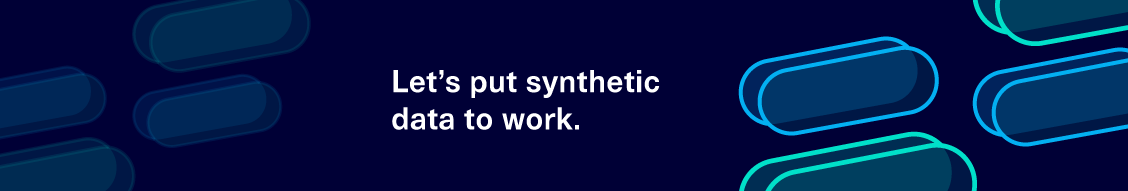